# Proyecto Final — Parte I: Análisis Inicial de Datos
## Modelos de Clasificación en Machine Learning
---

### Punto 1 · Leer los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

# Cargar el CSV desde el mismo directorio que este notebook
df = pd.read_csv('Datos_pr.csv', encoding='latin1')

print('✔ Archivo cargado exitosamente')
print(f'   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

✔ Archivo cargado exitosamente
   Dimensiones: 59,999 filas × 62 columnas


,ï»¿ID_Respuesta,You regularly make new friends.,You spend a lot of your free time exploring various random topics that pique your interest,Seeing other people cry can easily make you feel like you want to cry too,You often make a backup plan for a backup plan.,"You usually stay calm, even under a lot of pressure","At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",You prefer to completely finish one project before starting another.,You are very sentimental.,You like to use organizing tools like schedules and lists.,...,You believe that pondering abstract philosophical questions is a waste of time.,"You feel more drawn to places with busy, bustling atmospheres than quiet, intimate places.",You know at first glance how someone is feeling.,You often feel overwhelmed.,You complete things methodically without skipping over any steps.,You are very intrigued by things labeled as controversial.,You would pass along a good opportunity if you thought someone else needed it more.,You struggle with deadlines.,You feel confident that things will work out for you.,Personalidad
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,-1,0,0,0,0,0,ENFP
1,1,0,0,-2,-3,-1,2,-2,0,3,...,0,-2,0,2,0,-1,-1,-1,3,ISFP
2,2,0,0,2,0,-1,2,0,0,1,...,0,2,0,2,-1,0,1,2,1,INFJ


---
### Punto 2 · Preguntas de la encuesta (inglés original)

In [2]:
preguntas_originales = [c for c in df.columns if c not in ('Response Id', 'Personality')]

print(f'Total de preguntas: {len(preguntas_originales)}\n')
for i, q in enumerate(preguntas_originales, 1):
    print(f'  Q{i:02d}: {q}')

Total de preguntas: 62

  Q01: ï»¿ID_Respuesta
  Q02: You regularly make new friends.
  Q03: You spend a lot of your free time exploring various random topics that pique your interest
  Q04: Seeing other people cry can easily make you feel like you want to cry too
  Q05: You often make a backup plan for a backup plan.
  Q06: You usually stay calm, even under a lot of pressure
  Q07: At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know
  Q08: You prefer to completely finish one project before starting another.
  Q09: You are very sentimental.
  Q10: You like to use organizing tools like schedules and lists.
  Q11: Even a small mistake can cause you to doubt your overall abilities and knowledge.
  Q12: You feel comfortable just walking up to someone you find interesting and striking up a conversation.
  Q13: You are not too interested in discussing various interpretations and analyses of creative works.
  Q14: You are more incl

---
### Punto 3 · Traducir nombres de columnas al español

In [3]:
traduccion = {
    'Response Id': 'ID_Respuesta',
    'You regularly make new friends.':
        'Haces nuevos amigos con regularidad.',
    'You spend a lot of your free time exploring various random topics that pique your interest':
        'Dedicas mucho tiempo libre a explorar temas variados que despiertan tu curiosidad.',
    'Seeing other people cry can easily make you feel like you want to cry too':
        'Ver a otras personas llorar fácilmente te hace querer llorar también.',
    'You often make a backup plan for a backup plan.':
        'A menudo haces un plan de respaldo para tu plan de respaldo.',
    'You usually stay calm, even under a lot of pressure':
        'Generalmente te mantienes calmado/a incluso bajo mucha presión.',
    'At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know':
        'En eventos sociales, rara vez intentas presentarte con personas nuevas y prefieres hablar con quienes ya conoces.',
    'You prefer to completely finish one project before starting another.':
        'Prefieres terminar completamente un proyecto antes de comenzar otro.',
    'You are very sentimental.':
        'Eres muy sentimental.',
    'You like to use organizing tools like schedules and lists.':
        'Te gusta usar herramientas de organización como agendas y listas.',
    'Even a small mistake can cause you to doubt your overall abilities and knowledge.':
        'Incluso un pequeño error puede hacerte dudar de tus habilidades y conocimientos.',
    'You feel comfortable just walking up to someone you find interesting and striking up a conversation.':
        'Te sientes cómodo/a acercándote a alguien que te parece interesante para entablar conversación.',
    'You are not too interested in discussing various interpretations and analyses of creative works.':
        'No te interesa mucho discutir distintas interpretaciones y análisis de obras creativas.',
    'You are more inclined to follow your head than your heart.':
        'Te inclinas más a seguir tu cabeza que tu corazón.',
    'You usually prefer just doing what you feel like at any given moment instead of planning a particular daily routine.':
        'Generalmente prefieres hacer lo que se te antoja en el momento en lugar de planificar una rutina diaria.',
    'You rarely worry about whether you make a good impression on people you meet.':
        'Rara vez te preocupa si causas buena impresión en las personas que conoces.',
    'You enjoy participating in group activities.':
        'Disfrutas participar en actividades grupales.',
    'You like books and movies that make you come up with your own interpretation of the ending.':
        'Te gustan los libros y películas que te invitan a crear tu propia interpretación del final.',
    'Your happiness comes more from helping others accomplish things than your own accomplishments.':
        'Tu felicidad proviene más de ayudar a otros a lograr cosas que de tus propios logros.',
    'You are interested in so many things that you find it difficult to choose what to try next.':
        'Te interesan tantas cosas que te resulta difícil elegir qué intentar a continuación.',
    'You are prone to worrying that things will take a turn for the worse.':
        'Tiendes a preocuparte de que las cosas empeoren.',
    'You avoid leadership roles in group settings.':
        'Evitas los roles de liderazgo en entornos grupales.',
    'You are definitely not an artistic type of person.':
        'Definitivamente no eres una persona artística.',
    'You think the world would be a better place if people relied more on rationality and less on their feelings.':
        'Crees que el mundo sería mejor si las personas confiaran más en la razón y menos en sus emociones.',
    'You prefer to do your chores before allowing yourself to relax.':
        'Prefieres hacer tus tareas antes de permitirte relajar.',
    'You enjoy watching people argue.':
        'Disfrutas ver a las personas discutir.',
    'You tend to avoid drawing attention to yourself.':
        'Tiendes a evitar llamar la atención sobre ti mismo/a.',
    'Your mood can change very quickly.':
        'Tu estado de ánimo puede cambiar muy rápidamente.',
    'You lose patience with people who are not as efficient as you.':
        'Pierdes la paciencia con personas que no son tan eficientes como tú.',
    'You often end up doing things at the last possible moment.':
        'A menudo terminas haciendo las cosas en el último momento posible.',
    'You have always been fascinated by the question of what, if anything, happens after death.':
        'Siempre te ha fascinado la pregunta de qué sucede, si es que algo sucede, después de la muerte.',
    'You usually prefer to be around others rather than on your own.':
        'Generalmente prefieres estar rodeado/a de otros antes que estar solo/a.',
    'You become bored or lose interest when the discussion gets highly theoretical.':
        'Te aburres o pierdes el interés cuando la discusión se vuelve muy teórica.',
    'You find it easy to empathize with a person whose experiences are very different from yours.':
        'Te resulta fácil empatizar con una persona cuyas experiencias son muy distintas a las tuyas.',
    'You usually postpone finalizing decisions for as long as possible.':
        'Generalmente pospones la toma de decisiones el mayor tiempo posible.',
    'You rarely second-guess the choices that you have made.':
        'Rara vez cuestionas las decisiones que has tomado.',
    'After a long and exhausting week, a lively social event is just what you need.':
        'Después de una semana larga y agotadora, un evento social animado es justo lo que necesitas.',
    'You enjoy going to art museums.':
        'Disfrutas visitar museos de arte.',
    'You often have a hard time understanding other people\x92s feelings.':
        'A menudo te cuesta entender los sentimientos de otras personas.',
    'You like to have a to-do list for each day.':
        'Te gusta tener una lista de tareas para cada día.',
    'You rarely feel insecure.':
        'Rara vez te sientes inseguro/a.',
    'You avoid making phone calls.':
        'Evitas hacer llamadas telefónicas.',
    'You often spend a lot of time trying to understand views that are very different from your own.':
        'A menudo dedicas mucho tiempo a comprender puntos de vista muy diferentes a los tuyos.',
    'In your social circle, you are often the one who contacts your friends and initiates activities.':
        'En tu círculo social, a menudo eres quien contacta a los amigos e inicia actividades.',
    'If your plans are interrupted, your top priority is to get back on track as soon as possible.':
        'Si tus planes se interrumpen, tu principal prioridad es retomar el rumbo lo antes posible.',
    'You are still bothered by mistakes that you made a long time ago.':
        'Aún te molestan los errores que cometiste hace mucho tiempo.',
    'You rarely contemplate the reasons for human existence or the meaning of life.':
        'Rara vez contemplas las razones de la existencia humana o el significado de la vida.',
    'Your emotions control you more than you control them.':
        'Tus emociones te controlan más de lo que tú las controlas.',
    'You take great care not to make people look bad, even when it is completely their fault.':
        'Tienes mucho cuidado de no hacer quedar mal a las personas, incluso cuando es completamente su culpa.',
    'Your personal work style is closer to spontaneous bursts of energy than organized and consistent efforts.':
        'Tu estilo de trabajo personal se acerca más a ráfagas espontáneas de energía que a esfuerzos organizados y constantes.',
    'When someone thinks highly of you, you wonder how long it will take them to feel disappointed in you.':
        'Cuando alguien piensa bien de ti, te preguntas cuánto tiempo tardará en decepcionarse.',
    'You would love a job that requires you to work alone most of the time.':
        'Te encantaría un trabajo que requiera trabajar solo/a la mayor parte del tiempo.',
    'You believe that pondering abstract philosophical questions is a waste of time.':
        'Crees que reflexionar sobre preguntas filosóficas abstractas es una pérdida de tiempo.',
    'You feel more drawn to places with busy, bustling atmospheres than quiet, intimate places.':
        'Te atraen más los lugares con ambientes animados y concurridos que los lugares tranquilos e íntimos.',
    'You know at first glance how someone is feeling.':
        'Sabes a primera vista cómo se siente alguien.',
    'You often feel overwhelmed.':
        'A menudo te sientes abrumado/a.',
    'You complete things methodically without skipping over any steps.':
        'Completas las cosas de forma metódica sin saltarte ningún paso.',
    'You are very intrigued by things labeled as controversial.':
        'Te intrigan mucho las cosas catalogadas como controvertidas.',
    'You would pass along a good opportunity if you thought someone else needed it more.':
        'Cederías una buena oportunidad si creyeras que alguien más la necesita.',
    'You struggle with deadlines.':
        'Te cuesta cumplir con los plazos.',
    'You feel confident that things will work out for you.':
        'Te sientes seguro/a de que las cosas saldrán bien para ti.',
    'Personality': 'Personalidad',
}

df_trad = df.rename(columns=traduccion)

print('✔ Columnas renombradas al español\n')
print('Vista previa del dataframe traducido:')
df_trad.head(3)

✔ Columnas renombradas al español

Vista previa del dataframe traducido:


,ï»¿ID_Respuesta,Haces nuevos amigos con regularidad.,Dedicas mucho tiempo libre a explorar temas variados que despiertan tu curiosidad.,Ver a otras personas llorar fácilmente te hace querer llorar también.,A menudo haces un plan de respaldo para tu plan de respaldo.,Generalmente te mantienes calmado/a incluso bajo mucha presión.,"En eventos sociales, rara vez intentas presentarte con personas nuevas y prefieres hablar con quienes ya conoces.",Prefieres terminar completamente un proyecto antes de comenzar otro.,Eres muy sentimental.,Te gusta usar herramientas de organización como agendas y listas.,...,Crees que reflexionar sobre preguntas filosóficas abstractas es una pérdida de tiempo.,Te atraen más los lugares con ambientes animados y concurridos que los lugares tranquilos e íntimos.,Sabes a primera vista cómo se siente alguien.,A menudo te sientes abrumado/a.,Completas las cosas de forma metódica sin saltarte ningún paso.,Te intrigan mucho las cosas catalogadas como controvertidas.,Cederías una buena oportunidad si creyeras que alguien más la necesita.,Te cuesta cumplir con los plazos.,Te sientes seguro/a de que las cosas saldrán bien para ti.,Personalidad
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,-1,0,0,0,0,0,ENFP
1,1,0,0,-2,-3,-1,2,-2,0,3,...,0,-2,0,2,0,-1,-1,-1,3,ISFP
2,2,0,0,2,0,-1,2,0,0,1,...,0,2,0,2,-1,0,1,2,1,INFJ


---
### Punto 4 · Guardar el dataframe traducido en `datos_trad.csv`

In [4]:
df_trad.to_csv('datos_trad.csv', index=False, encoding='utf-8-sig')
print('✔ Archivo "datos_trad.csv" guardado en el mismo directorio que este notebook.')

✔ Archivo "datos_trad.csv" guardado en el mismo directorio que este notebook.


---
### Punto 5 · Número de registros

In [5]:
n_registros = len(df_trad)
n_columnas  = len(df_trad.columns)
n_preguntas = n_columnas - 2  # descontando ID_Respuesta y Personalidad

resumen = pd.DataFrame({
    'Métrica': ['Total de registros (encuestados)',
                'Total de columnas',
                'Preguntas de encuesta',
                'Columnas de control'],
    'Valor': [f'{n_registros:,}',
              f'{n_columnas}',
              f'{n_preguntas}',
              'ID_Respuesta, Personalidad']
})
resumen

,Métrica,Valor
0,Total de registros (encuestados),"59,999"
1,Total de columnas,62
2,Preguntas de encuesta,60
3,Columnas de control,"ID_Respuesta, Personalidad"


---
### Punto 6 · Número de personas por tipo de personalidad

In [6]:
conteo = df_trad['Personalidad'].value_counts().sort_values(ascending=False)
print('Conteo por tipo de personalidad:')
print(conteo.to_string())

Conteo por tipo de personalidad:
Personalidad
ESFP    3769
INFJ    3761
ENFP    3760
ENTP    3760
ESTJ    3759
ISTJ    3756
ISTP    3755
ESTP    3749
ISFP    3746
ESFJ    3746
ENFJ    3743
INTJ    3743
INTP    3742
ISFJ    3739
ENTJ    3737
INFP    3734


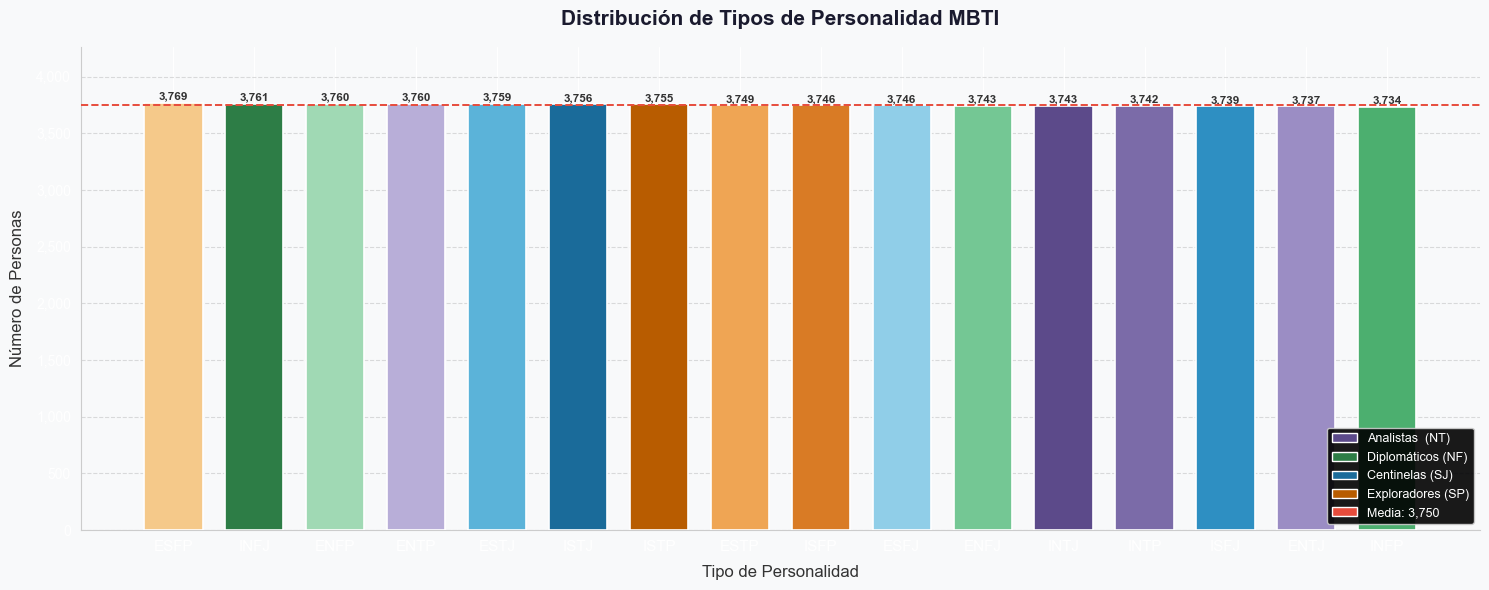

In [7]:
# ── Paleta de colores por grupo temperamental MBTI ──────────────────────────
paleta = {
    # Analistas (morado)
    'INTJ': '#5C4A8A', 'INTP': '#7B6BA8', 'ENTJ': '#9B8DC4', 'ENTP': '#B8AED8',
    # Diplomáticos (verde)
    'INFJ': '#2D7D46', 'INFP': '#4CAF6F', 'ENFJ': '#74C794', 'ENFP': '#A0D9B4',
    # Centinelas (azul)
    'ISTJ': '#1A6B9A', 'ISFJ': '#2E8FC2', 'ESTJ': '#5BB3D9', 'ESFJ': '#90CEE8',
    # Exploradores (naranja)
    'ISTP': '#B85C00', 'ISFP': '#D97B25', 'ESTP': '#EFA554', 'ESFP': '#F5C98A',
}
colores = [paleta.get(p, '#888888') for p in conteo.index]

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(
    conteo.index, conteo.values,
    color=colores, edgecolor='white', linewidth=1.2, width=0.72,
    zorder=3
)

# Etiqueta numérica encima de cada barra
for bar, val in zip(bars, conteo.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 12,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold', color='#333333'
    )

# Línea de media
media = conteo.mean()
ax.axhline(media, color='#E74C3C', linewidth=1.4, linestyle='--', zorder=4,
           label=f'Media: {media:,.0f}')

# Leyenda de grupos temperamentales
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#5C4A8A', label='Analistas  (NT)'),
    Patch(facecolor='#2D7D46', label='Diplomáticos (NF)'),
    Patch(facecolor='#1A6B9A', label='Centinelas (SJ)'),
    Patch(facecolor='#B85C00', label='Exploradores (SP)'),
    Patch(facecolor='#E74C3C', label=f'Media: {media:,.0f}'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9,
          framealpha=0.9, edgecolor='#CCCCCC')

# Ejes y etiquetas
ax.set_title(
    'Distribución de Tipos de Personalidad MBTI',
    fontsize=15, fontweight='bold', pad=16, color='#1A1A2E'
)
ax.set_xlabel('Tipo de Personalidad', fontsize=12, labelpad=8, color='#333333')
ax.set_ylabel('Número de Personas', fontsize=12, labelpad=8, color='#333333')
ax.set_ylim(0, conteo.max() * 1.13)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#AAAAAA', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('grafica_personalidades.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
### Punto 7 · Descripción de cada grupo de personalidad

In [8]:
descripcion_mbti = {
    # ── ANALISTAS (NT) ─────────────────────────────────────────────────────
    'INTJ': ('El Arquitecto',      'Analistas',
             'Estratega independiente e imaginativo. Planifica con visión a largo plazo, '
             'confía en la lógica y es perfeccionista. Prefiere trabajar solo.'),
    'INTP': ('El Lógico',          'Analistas',
             'Pensador analítico e innovador que busca patrones y teorías. '
             'Disfruta resolver problemas complejos de forma independiente.'),
    'ENTJ': ('El Comandante',      'Analistas',
             'Líder nato, asertivo y orientado a metas. Toma decisiones rápidas '
             'y dirige equipos con eficiencia y determinación.'),
    'ENTP': ('El Innovador',       'Analistas',
             'Creativo y extrovertido; ama debatir ideas y encontrar soluciones '
             'originales. Entusiasta, curioso e impulsivo ante los desafíos.'),
    # ── DIPLOMÁTICOS (NF) ──────────────────────────────────────────────────
    'INFJ': ('El Defensor',        'Diplomáticos',
             'Idealista, empático y reservado. Tiene una visión clara de cómo '
             'mejorar el mundo y lucha por sus valores con determinación.'),
    'INFP': ('El Mediador',        'Diplomáticos',
             'Soñador, empático y fiel a sus principios. Busca el sentido profundo '
             'de las cosas y valora la autenticidad por encima de todo.'),
    'ENFJ': ('El Protagonista',    'Diplomáticos',
             'Carismático y orientado a las personas. Inspira y motiva a los demás, '
             'con gran habilidad para entender y gestionar emociones ajenas.'),
    'ENFP': ('El Activista',       'Diplomáticos',
             'Entusiasta, creativo y sociable. Ve el potencial en cada persona y '
             'situación; disfruta conectar ideas y emociones con los demás.'),
    # ── CENTINELAS (SJ) ────────────────────────────────────────────────────
    'ISTJ': ('El Logístico',       'Centinelas',
             'Responsable, ordenado y confiable. Sigue normas establecidas, es '
             'muy detallista y siempre cumple con sus compromisos.'),
    'ISFJ': ('El Protector',       'Centinelas',
             'Cálido, paciente y servicial. Se preocupa profundamente por el '
             'bienestar ajeno y es fiel a sus tradiciones y responsabilidades.'),
    'ESTJ': ('El Ejecutivo',       'Centinelas',
             'Práctico, decidido y organizador. Valora el orden y la eficiencia; '
             'excelente administrando sistemas y liderando personas.'),
    'ESFJ': ('El Cónsul',          'Centinelas',
             'Sociable y solícito; vive para ayudar a los demás. Muy sensible a '
             'las necesidades de su entorno y busca la armonía grupal.'),
    # ── EXPLORADORES (SP) ──────────────────────────────────────────────────
    'ISTP': ('El Virtuoso',        'Exploradores',
             'Observador, práctico y tranquilo. Aprende haciendo; le fascina '
             'entender cómo funcionan las cosas y resolver problemas técnicos.'),
    'ISFP': ('El Aventurero',      'Exploradores',
             'Artístico, sensible y reservado. Vive el presente con intensidad '
             'y expresa su creatividad de formas únicas y personales.'),
    'ESTP': ('El Empresario',      'Exploradores',
             'Energético, pragmático y audaz. Actúa antes de pensar, disfruta '
             'el riesgo y tiene gran habilidad para leer a las personas.'),
    'ESFP': ('El Animador',        'Exploradores',
             'Espontáneo, energético y divertido. Ama ser el centro de atención, '
             'disfruta la vida al máximo y es muy generoso con los demás.'),
}

filas = []
for tipo in conteo.index:
    nombre, grupo, desc = descripcion_mbti[tipo]
    filas.append({
        'Tipo': tipo,
        'Nombre': nombre,
        'Grupo Temperamental': grupo,
        'Descripción': desc,
        'Registros': conteo[tipo],
    })

tabla = pd.DataFrame(filas)

# Estilo visual para el DataFrame
grupo_color = {
    'Analistas':    'background-color: #E8E3F5',
    'Diplomáticos': 'background-color: #DFF2E8',
    'Centinelas':   'background-color: #D6EAF8',
    'Exploradores': 'background-color: #FDEBD0',
}

def colorear_fila(row):
    color = grupo_color.get(row['Grupo Temperamental'], '')
    return [color] * len(row)

tabla.style\
    .apply(colorear_fila, axis=1)\
    .set_properties(**{'text-align': 'left'})\
    .hide(axis='index')

Tipo,Nombre,Grupo Temperamental,Descripción,Registros
ESFP,El Animador,Exploradores,"Espontáneo, energético y divertido. Ama ser el centro de atención, disfruta la vida al máximo y es muy generoso con los demás.",3769
INFJ,El Defensor,Diplomáticos,"Idealista, empático y reservado. Tiene una visión clara de cómo mejorar el mundo y lucha por sus valores con determinación.",3761
ENFP,El Activista,Diplomáticos,"Entusiasta, creativo y sociable. Ve el potencial en cada persona y situación; disfruta conectar ideas y emociones con los demás.",3760
ENTP,El Innovador,Analistas,"Creativo y extrovertido; ama debatir ideas y encontrar soluciones originales. Entusiasta, curioso e impulsivo ante los desafíos.",3760
ESTJ,El Ejecutivo,Centinelas,"Práctico, decidido y organizador. Valora el orden y la eficiencia; excelente administrando sistemas y liderando personas.",3759
ISTJ,El Logístico,Centinelas,"Responsable, ordenado y confiable. Sigue normas establecidas, es muy detallista y siempre cumple con sus compromisos.",3756
ISTP,El Virtuoso,Exploradores,"Observador, práctico y tranquilo. Aprende haciendo; le fascina entender cómo funcionan las cosas y resolver problemas técnicos.",3755
ESTP,El Empresario,Exploradores,"Energético, pragmático y audaz. Actúa antes de pensar, disfruta el riesgo y tiene gran habilidad para leer a las personas.",3749
ISFP,El Aventurero,Exploradores,"Artístico, sensible y reservado. Vive el presente con intensidad y expresa su creatividad de formas únicas y personales.",3746
ESFJ,El Cónsul,Centinelas,Sociable y solícito; vive para ayudar a los demás. Muy sensible a las necesidades de su entorno y busca la armonía grupal.,3746
